# Realce no Domínio Espacial

**O que é realce no domínio espacial?**
O realce de imagem é um conjunto de técnicas de processamento que as deixam mais aprimoradas, acentuando características e melhorando a qualidade visual, sendo dividido em:
* realce no domíno espacial
* realce no domínio de frequência

O domínio espacial representa as imagens através de pixels e valores de brilho em cada posição, por isso as técnicas desse domínio manipulam diretamente os pixels da matriz da imagem e dividem-se em:
* processamento de ponto
* processamento de vizinhança


## Processamento ponto a ponto
Em operações **ponto a ponto cada ponto de saía depende apenas do seu correspondente na imagem de entrada**, ou seja se trabalha apenas com um pixel por vez e não são considerados pixels vizinhos.

Matematicamente uma função é aplicada em capa pixel de maneira isolada gerando um novo valor de pixel como saída.

Em relação a classificação de funções de transformação ponto a ponto, tem-se três tipos.
* *Funções lineares*
  * Identidade
  * Negativo
* *Funções logarítmicas*
  * log
  * inverso de log
* *Funções de pontência*
  * correção gama

### Lineares
Dividindo-se em identidade e negativo, é importante destacar que apenas a segunda será trabalhada em código pois a primeira tem como resultado a própria entrada.

A tranformação em negativo é obtida **calculando o complemento dos valores de intensidade original dos pixels**, ou seja se a intensidade original é *"r"* e a intensidade negativa é *"s"* a operação é calculada através de **s = L - 1 - r**, com "L" sendo o nível máximo de intensidade na imagem (geralmente é 255 em imagens de 8 bits).

ps: analisando a equação anterior nota-se que ***s é justamente o que falta para que o valor atual (r) atinja a intensidade máxima da imagem***.

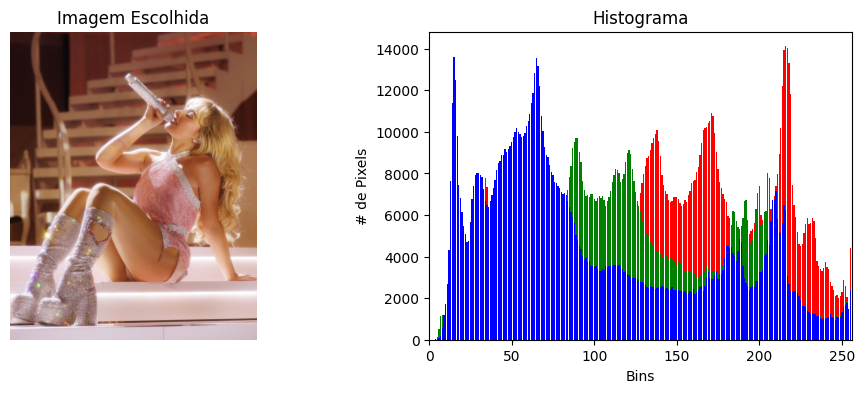

In [ ]:
import cv2
import matplotlib.pyplot as plt

img_brg = cv2.imread('/content/imagens/imagem_colorida.jpg')

colors = ('r', 'g', 'b')
img_color_rgb = cv2.cvtColor(img_brg, cv2.COLOR_BGR2RGB)

#separando os canais da imagem
#a ordem é red, green e blue pois eu converti
chans = cv2.split(img_color_rgb)

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

#plotando a imagem
ax1.set_title("Imagem Escolhida")
ax1.axis("off")
ax1.imshow(img_color_rgb)

#plotando o histograma da imagem
ax2.set_title("Histograma")
ax2.set_xlabel("Bins")
ax2.set_ylabel("# de Pixels")

#loop para os canais da imagem
for (chan, color) in zip(chans, colors):
  hist = cv2.calcHist([chan], [0], None, [256], [0, 256])
  ax2.bar(range(256), hist.flatten(), color=color)
  ax2.set_xlim([0, 256])


O próximo código apresenta a lógica por trás da operação de transformação, apenas deve ser executada a motivo de curiosidade.

In [ ]:
# #a operação de negativo manualmente

# #altura e largura da imagem
# height, width, _ = img_color_rgb.shape

# for i in range(0, height - 1):
#   for j in range(0, width - 1):

#     #valor de cada pixel específico
#     pixel = img_color_rgb[i, j]

#     #transformação negativo para cada canal

#     #canal red
#     pixel[0] = 255 - pixel[0]

#     #canal green
#     pixel[1] = 255 - pixel[1]

#     #canal blue
#     pixel[2] = 255 - pixel[2]

#     #armazenando os valores novo
#     img_color_rgb[i, j] = pixel

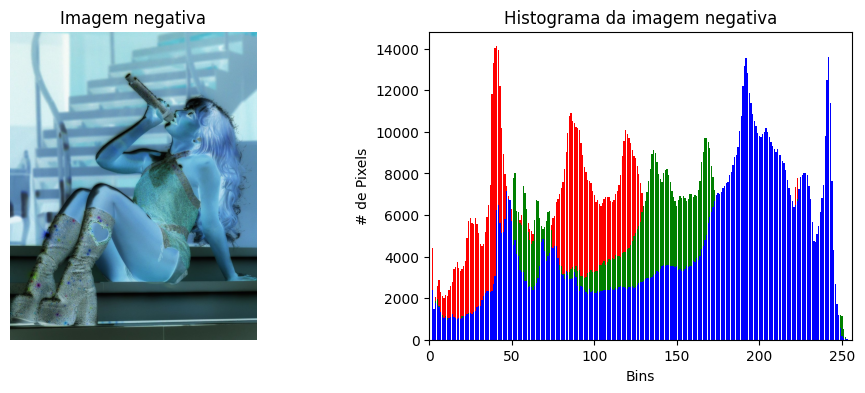

In [ ]:
#maneira mais simples de usar a operação de negativo
img_neg = 1 - img_color_rgb

fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 4))

#exibindo a imagem pós-transformação
ax3.axis("off")
ax3.set_title("Imagem negativa")
ax3.imshow(img_neg)

#plotando o histograma
ax4.set_title("Histograma da imagem negativa")
ax4.set_xlabel("Bins")
ax4.set_ylabel("# de Pixels")

#separando os canais novamente
chans = cv2.split(img_neg)

#loop para os canais
for (chan, color) in zip(chans, colors):
    hist = cv2.calcHist([chan], [0], None, [256], [0, 256])
    ax4.bar(range(256), hist.flatten(), color=color)
    ax4.set_xlim([0, 256])

Algumas observações importantes que podem ser feitas em relação a transformação negativo:
* O histograma da imagem negativa é o ***inverso horizontal*** do histograma original, o que faz sentido pois nessa operação os pixels pretos viram brancos e os pixels brancos viram pretos.
* Mesmo após a transformação a imagem contínua tendo três canais.

### Logarítimicas

Essas transformações **são úteis em imagens que tem uma ampla gama de valores de pixel**, como as que foram capturadas em condições de **baixa luminosidade** ou **alto constraste**. Dividem-se em: logarítmica e logarítmica inversa.

A transformação logarítmica aplica a função logarítmica a cada valor de pixel da imagem, distribuindo os valores de pixels mais escuros e tornando as regiões sombreadas mais visíveis. Sendo utilizada a equação **S = c * log(1 + R)** com S representando o valor do pixel transformado, R o valor original e c uma constante de aprimoramento, que é utilizada para garantir que o valor final caiba dentro do intervalo dinâmico suportado pela imagem — *é calculado pela equação c = 255 / (log (1 + max)) sendo max o maior valor de pixel da imagem*.



Em resumo: a logarítmica comprime valores de alta intensidade e alonga os de baixa intensidade.

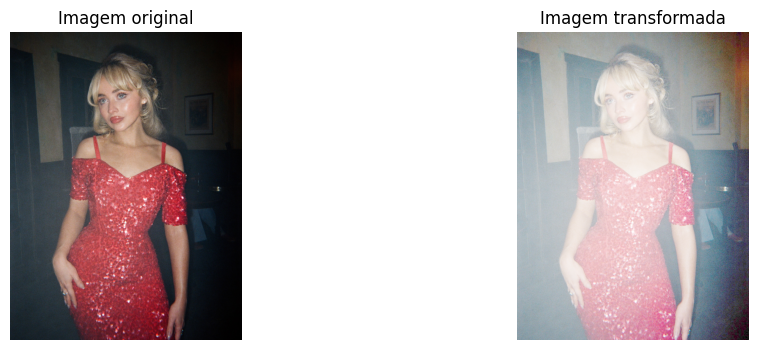

In [ ]:
import numpy
img2 = cv2.imread('/content/imagens/imagem2.jpg')
image2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

image2_float = image2.astype(numpy.float64)

#calculando a constante
c = 255 / numpy.log(1 + numpy.max(image2_float))
log_image = c * (numpy.log(image2_float + 1))

#convertendo os dados de float para int
log_image = numpy.array(log_image, dtype= numpy.uint8)

fig3, (ax5, ax6) = plt.subplots(1, 2, figsize=(12, 4))

ax5.axis("off")
ax5.set_title("Imagem original")
ax5.imshow(image2)

ax6.axis("off")
ax6.set_title("Imagem transformada")
ax6.imshow(log_image)

plt.show()

Um ponto relevante desse tipo de operação é a linha que converte os dados da imagem de float para int após a transformação. Isso foi realizado porque o ***padrão de imagens digitais costuma ser uint8*** e ***ao aplicar a transformação logarítmica em uma imagem os valores de pixels resultantes são float***, o que pode causar problemas pois a maioria das funções da OpenCV e do matplotlib esperam valores normalizados entre 0.0 e 1.0.

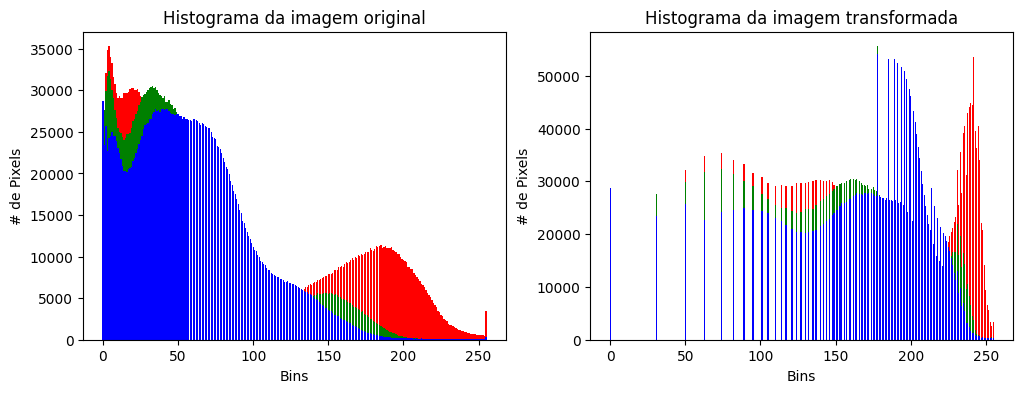

In [ ]:
#histogramas das imagens

chans_img1 = cv2.split(image2)
chans_img2 = cv2.split(log_image)

fig4, (ax7, ax8) = plt.subplots(1, 2, figsize=(12, 4))


ax7.set_title("Histograma da imagem original")
ax7.set_xlabel("Bins")
ax7.set_ylabel("# de Pixels")

for (chan, color) in zip(chans_img1, colors):
  hist1 = cv2.calcHist([chan], [0], None, [256], [0, 256])
  ax7.bar(range(256), hist1.flatten(), color=color)


ax8.set_title("Histograma da imagem transformada")
ax8.set_xlabel("Bins")
ax8.set_ylabel("# de Pixels")

for (chan, color) in zip(chans_img2, colors):
  hist2 = cv2.calcHist([chan], [0], None, [256], [0, 256])
  ax8.bar(range(256), hist2.flatten(), color=color)



Observa-se nos resultados anteriores que a imagem ficou com um aspecto estranho. ***Isso ocorreu pois a constante foi calculada sobre os três canais juntos, ou seja ela é o maxímo global da imagem, porém cada canal tem seu máximo global***.

Portanto, para solucionar esse problema será isolado o brilho das cores usando o modelo HSV (Hue, Saturation, Valeu/Matiz, Saturação, Valor).

In [ ]:
#convertendo de rgb para hsv e separando os canais
hsv_img = cv2.cvtColor(image2, cv2.COLOR_RGB2HSV)
h, s, v = cv2.split(hsv_img)

#operação de logaritmo apenas no canal V (value/brilho)
v_float = v.astype(numpy.float64)

c = 255 / numpy.log(1 + (numpy.max(v_float)))
v_log = c * numpy.log(1 + v_float)

#conversão para int e truncamento de valores abaixo ou acima do limite (0, 255)
v_transformed = numpy.clip(v_log, 0, 255).astype(numpy.uint8)

#juntando todos os canais e convertendo de volta para rgb
hsv_log = cv2.merge([h, s, v_transformed])
resultado_log = cv2.cvtColor(hsv_log, cv2.COLOR_HSV2RGB)


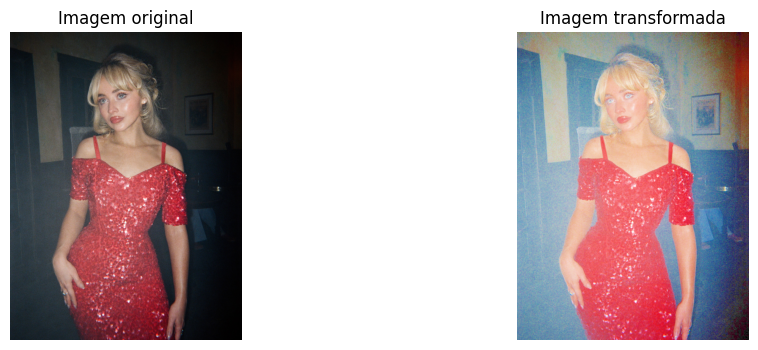

In [ ]:
fig5, (ax9, ax10) = plt.subplots(1, 2, figsize=(12, 4))

ax9.axis("off")
ax9.set_title("Imagem original")
ax9.imshow(image2)

ax10.axis("off")
ax10.set_title("Imagem transformada")
ax10.imshow(resultado_log)

plt.show()

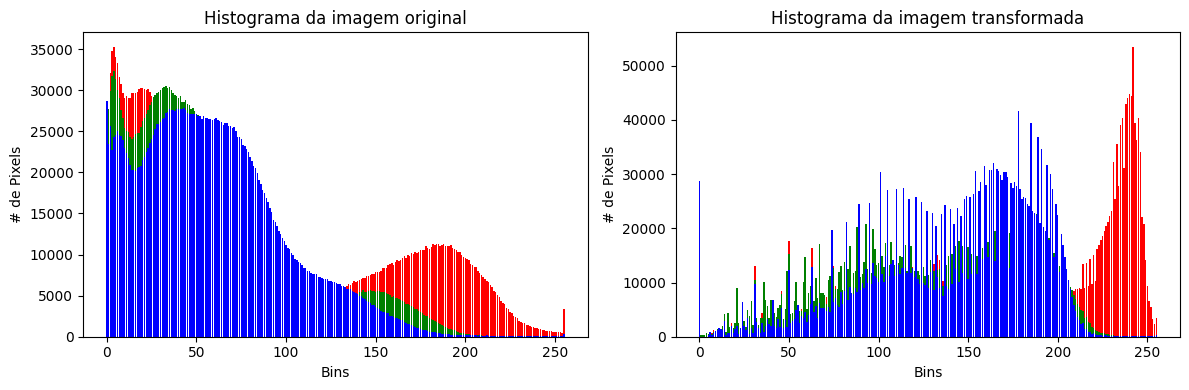

In [ ]:
#histogramas das imagens
chans_img4 = cv2.split(image2)
chans_img5 = cv2.split(resultado_log)

fig6, (ax11, ax12) = plt.subplots(1, 2, figsize=(12, 4))


ax11.set_title("Histograma da imagem original")
ax11.set_xlabel("Bins")
ax11.set_ylabel("# de Pixels")

for (chan, color) in zip(chans_img4, colors):
  hist3 = cv2.calcHist([chan], [0], None, [256], [0, 256])
  ax11.bar(range(256), hist3.flatten(), color=color)


ax12.set_title("Histograma da imagem transformada")
ax12.set_xlabel("Bins")
ax12.set_ylabel("# de Pixels")

for (chan, color) in zip(chans_img5, colors):
  hist4 = cv2.calcHist([chan], [0], None, [256], [0, 256])
  ax12.bar(range(256), hist4.flatten(), color=color)

fig6.tight_layout()

Ao comparar os dois histogramas das operações logarítmicas, são observadas diferenças consideráveis. No primeiro histograma existe lacunas vazias que expõem como cada cor sofreu distorções não-lineares, destruíndo a proporção entre os canais. Por sua vez, no segundo histograma as cores se mantiveram preservadas e sem tantas lacunas ou espaços vazios.

### Potência
Essas operações **são utilizadas para ajustar características tonais e de brilho de uma imagem**, por isso são utéis no processamento de imagens para aprimorar a qualidade visual e corrigir problemas relacionados à iluminação e constrate.

As transformações de potência elevam os valores dos pixels a uma determinada potência para, assim, ajustar o brilho e o contraste geral da imagem. Sendo a equação **O = k * Iʸ** (equação gama) utilizada nessas operações. "O" é o valor do pixel de saída, "k" é uma constante que ajusta o resultado na faixa de intensidade desejada, "y" é o expoente que controla o grau de transformação e "I" é o valor do pixel de entrada.

Em relação ao valor de y, quando ***y\<1*** a imagem é expandida para os tons escuros e quando ***y\>1*** é expandida para os tons claros. A título de curiosidade, essa técnica é a base para a calibração de constraste em monitores, impressoras e sensores de captura.

Quando y = 1, a transformação não tem efeito na imagem e a saída é a mesma que a entrada.

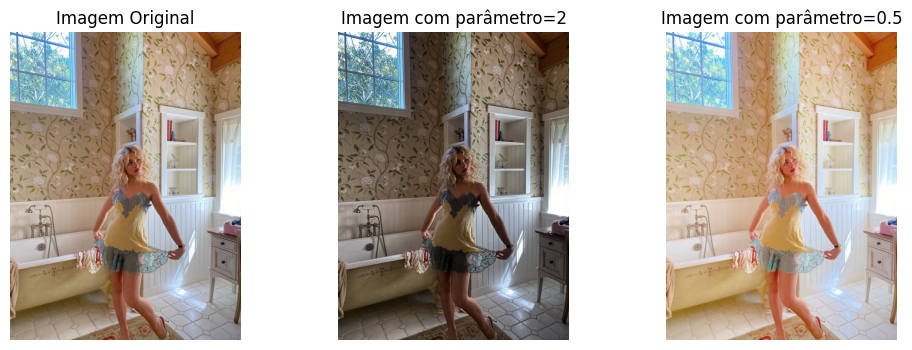

In [ ]:
img_3 = cv2.imread('/content/imagens/imagem3.jpg')
img3 = cv2.cvtColor(img_3, cv2.COLOR_BGR2RGB)

gamma_param, gamma2_param = 2, 0.5

def gamma(img, gamma):
  #aplicando uma tabela para calcular em cada pixel o valor
  lookUpTable = numpy.empty((1, 256), numpy.uint8)
  for i in range(256):
    lookUpTable[0, i] = numpy.clip(pow(i / 255.0, gamma) * 255.0, 0, 255)

  #aplicando o lookuptable apenas no canal de brilho
  img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
  img_hsv[:, :, 2] = cv2.LUT(img_hsv[:, :, 2], lookUpTable)

  img_processada = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)
  return img_processada

gamma_img1 = gamma(img3, gamma_param)
gamma_img2 = gamma(img3, gamma2_param)

fig7, (ax13, ax14, ax15) = plt.subplots(1, 3, figsize=(12, 4))

ax13.axis("off")
ax13.set_title("Imagem Original")
ax13.imshow(img3)

ax14.axis("off")
ax14.set_title("Imagem com parâmetro=2")
ax14.imshow(gamma_img1)

ax15.axis("off")
ax15.set_title("Imagem com parâmetro=0.5")
ax15.imshow(gamma_img2)

plt.show()
fig7.tight_layout()

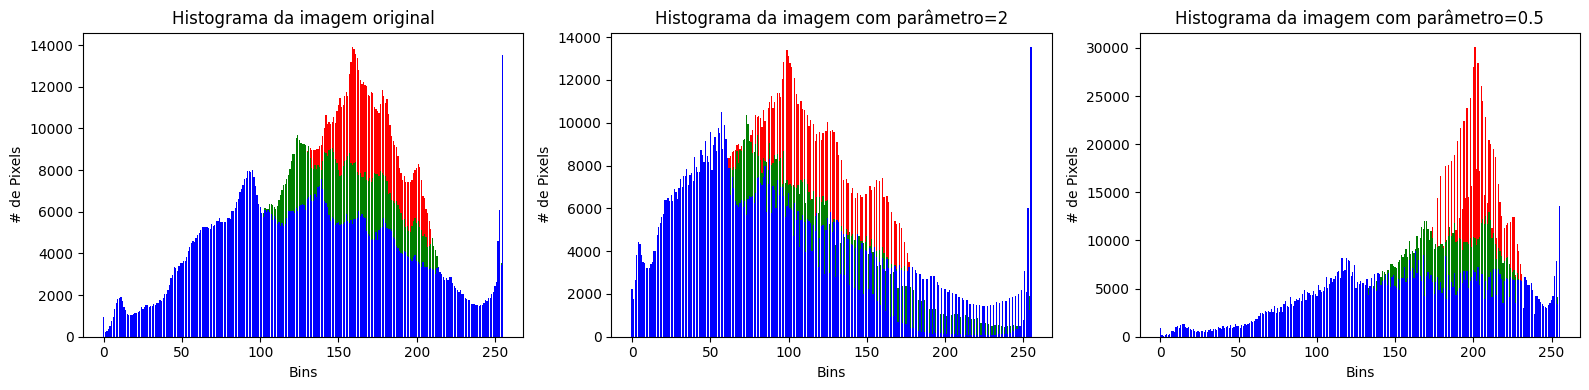

In [ ]:
#histogramas das imagens
chans1 = cv2.split(img3)
chans2 = cv2.split(gamma_img1)
chans3 = cv2.split(gamma_img2)

#plotando os histogramas
fig8, (ax16, ax17, ax18) = plt.subplots(1, 3, figsize=(16, 4))

ax16.set_title("Histograma da imagem original")
ax16.set_xlabel("Bins")
ax16.set_ylabel("# de Pixels")

for (chan, color) in zip(chans1, colors):
  hist5 = cv2.calcHist([chan], [0], None, [256], [0, 256])
  ax16.bar(range(256), hist5.flatten(), color=color)

ax17.set_title("Histograma da imagem com parâmetro=2")
ax17.set_xlabel("Bins")
ax17.set_ylabel("# de Pixels")

for (chan, color) in zip(chans2, colors):
  hist6 = cv2.calcHist([chan], [0], None, [256], [0, 256])
  ax17.bar(range(256), hist6.flatten(), color=color)

ax18.set_title("Histograma da imagem com parâmetro=0.5")
ax18.set_xlabel("Bins")
ax18.set_ylabel("# de Pixels")

for (chan, color) in zip(chans3, colors):
  hist7 = cv2.calcHist([chan], [0], None, [256], [0, 256])
  ax18.bar(range(256), hist7.flatten(), color=color)

fig8.tight_layout()

### Filtros Espaciais de Suavização ou Passa-Baixa
Eles são **ferramentas de processamento de imagens que ajudam a reduzir variações bruscas de intensidade entre pixels e eliminar ruídos**. Em relação ao funcionamento do filtro, ele permite que as frequências espaciais baixas passem enquanto diminui ou elimina as frequências altas.

Visto que uma imagem é uma matriz, cada um dos números representam a intensidade do pixel, um número baixo presenta um pixel escuro e um número alto representa um pixel claro. **O que o código de suavização faz é criar uma matriz baseada em uma janela de tamanho PxP e aplicar na imagem original, para assim calcular a média da região dos vizinhos e substituit o valor do pixel**. Dessa maneira as mudanças bruscas são eliminadas, tornando a diferença entre os valores dos pixels mais suave.

In [ ]:
def passa_baixa(img, kernel_size):
  #criando a janela de pixels com mesmo peso
  kernel = 1/(kernel_size**2)*numpy.ones((kernel_size, kernel_size))

  #percorrendo a imagem e calculando a combinação de pixels da vizinhança
  imagem_filtro = cv2.filter2D(img, -1, kernel)   #-1 significa que o tipo original vai ser mantido
  return imagem_filtro

É importante destacar que no código acima ***quanto maior o kernel_size maior a suavização***, e também a perda de detalhes/bordas.

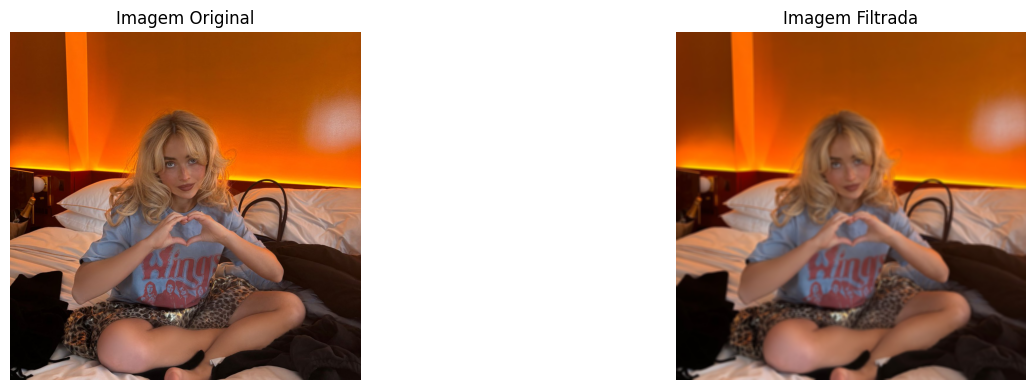

In [ ]:
img4 = cv2.imread('/content/imagens/imagem4.jpg')
imagem4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

imagem_filtrada = passa_baixa(imagem4, 10)

fig9, (ax19, ax20) = plt.subplots(1, 2, figsize=(16, 4))

ax19.axis("off")
ax19.set_title("Imagem Original")
ax19.imshow(imagem4)

ax20.axis("off")
ax20.set_title("Imagem Filtrada")
ax20.imshow(imagem_filtrada)

fig9.tight_layout()

Existe outra versão do filtro passa baixa, o **Gaussiano**, que é semelhante ao citado anteriormente, mas que não calcula os pesos igualmente. Em vez disso, prioriza os valores dos pixels mais próximos em detrimento dos mais afastados. Portanto o resultado final é mais suave/intuitivo.

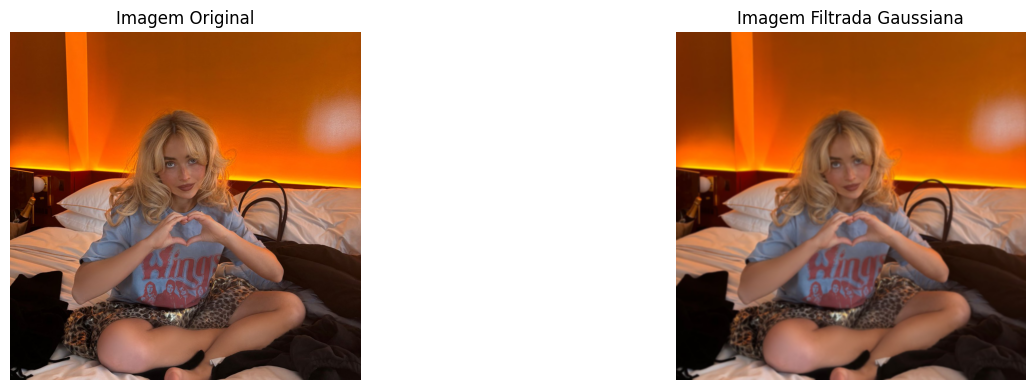

In [ ]:
img_gauss_filtro = cv2.GaussianBlur(imagem4, (11, 11), 0)

fig10, (ax21, ax22) = plt.subplots(1, 2, figsize=(16, 4))

ax21.axis("off")
ax21.set_title("Imagem Original")
ax21.imshow(imagem4)

ax22.axis("off")
ax22.set_title("Imagem Filtrada Gaussiana")
ax22.imshow(img_gauss_filtro)

fig10.tight_layout()

Algumas observações sobre o filtro gaussiano.
* o filtro gaussiano precisa ter um pixel central bem definido para colocar o kernel sobre cada pixel, por essa razão ***o valor do kernel precisa ser ímpar***.
* o valor de sigma = 0 (como está no código) diz a OpenCV que ***o sigma deve ser calculado automaticamente a partir do tamanho do kernel***.

### Filtros Espaciais de Realce de Nitidez ou Passa-Alta
É o processo oposto ao filtro de suavização, ou seja ***ele deixa a imagem mais nítida, destacando bordas, detalhes e favorecendo as altas frequências***. Porém, um ponto importante de destacar é que ao realçar os detalhes da imagem o ruído também aumenta.

O filtro mais utilizado para realce é o **Laplaciano**, que tem como **ponto ideial o seu centro** e o *valor dos coeficientes depende da proximidade com o centro, se forem próximos são positivos e se estiverem na periferia são negativos*. Ademais, a **soma dos coeficientes é zero**.

Visto que o Laplaciano é baseado na segunda derivada da imagem, ele verifica como a intensidade muda em relação aos pixels vizinhos. Então, a segunda derivada destaca a região onde a mudança de intensidade começa e termina, sendo muito sensível a bordas e detalhes.

Em relação ao valores que o centro pode assumir, se for negativo são removidas as bordas exteriores e se for positivo as bordas inferiores.

ps: antes do processamento ***é recomendado recortar os valores negativos dos pixels e não usar valores absoutos***, pois valores negativos podem gerar picos na imagem.


In [33]:
#exemplo com centro negativo
laplacian_kernelA1 = numpy.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
c = -2

#convertendo para YCrCb
brina_ycrcb = cv2.cvtColor(imagem4, cv2.COLOR_RGB2YCrCb)
y_canal, cr_canal, cb_canal = cv2.split(brina_ycrcb)

#convertendo apenas o canal de brilho na operação laplaciana
laplaciano_16s = cv2.filter2D(y_canal, cv2.CV_16S, laplacian_kernelA1)
y_16s = y_canal.astype(numpy.int16)

#equação de nitidez no brilho
sharp_y_16s = y_16s + (c * laplaciano_16s)
sharp_y_8u = numpy.clip(sharp_y_16s, 0, 255).astype(numpy.uint8)  #limites em 0-255

#jutando o canal de brilho com as outras cores
resultado = cv2.merge([sharp_y_8u, cr_canal, cb_canal])
resultado = cv2.cvtColor(resultado, cv2.COLOR_YCrCb2RGB)

#operação aplicada apenas no canal de brilho para exibição e comparação
laplaciano_visual = cv2.convertScaleAbs(laplaciano_16s)


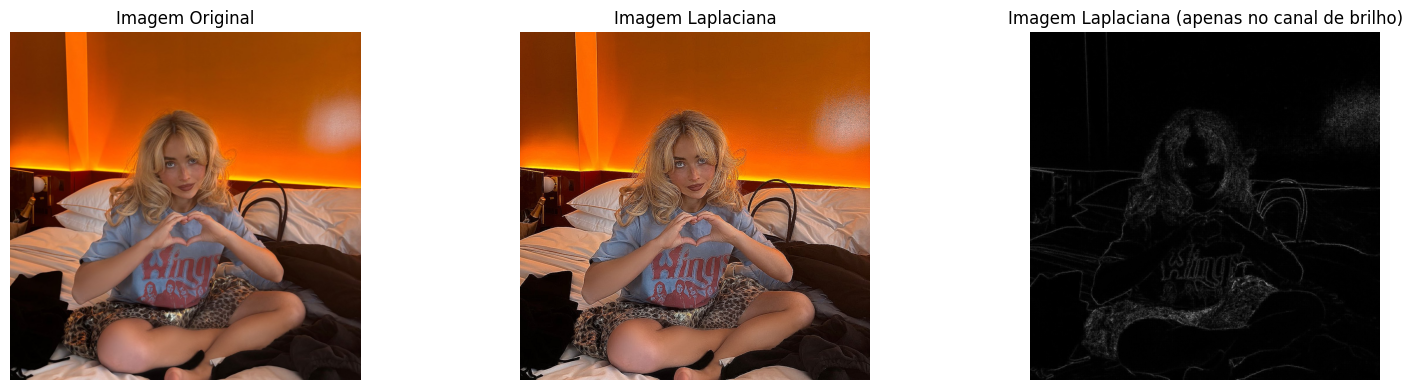

In [34]:
fig11, (ax23, ax24, ax25) = plt.subplots(1, 3, figsize=(16, 4))

ax23.axis("off")
ax23.set_title("Imagem Original")
ax23.imshow(imagem4)

ax24.axis("off")
ax24.set_title("Imagem Laplaciana")
ax24.imshow(resultado)

ax25.axis("off")
ax25.set_title("Imagem Laplaciana (apenas no canal de brilho)")
ax25.imshow(laplaciano_visual, cmap='gray')

fig11.tight_layout()

*Referências*


---

[Basic Intensity Transformation Functions and example with openCV
](https://medium.com/@khanhson0811/basic-intensity-transformation-functions-and-example-with-opencv-1a56932f34ac)



---
[Negative transformation of an image using Python and OpenCV
](https://www.geeksforgeeks.org/python/negative-transformation-of-an-image-using-python-and-opencv/)



---
[Image filtering](https://scikit-image.org/skimage-tutorials/lectures/1_image_filters.html)




---
[Image Sharpening](https://www.inf.ufsc.br/~aldo.vw/visao/khoros/html-dip/c6/s4/front-page.html)
